In [3]:
import pickle
from pathlib import Path

out_dir = Path("/Users/javier/FLAMES_30dor/gausspy_initial_test_regular_grid/gausspy_validation")

FILENAME_DATA = out_dir / "real_FLAMES_validation_input.pkl"
FILENAME_DATA_DECOMP = out_dir / "real_FLAMES_validation_decomposed.pkl"
FILENAME_DF_VALIDATION = out_dir / "df_validation.pkl"
FILENAME_CONFIG = out_dir / "validation_training_config.pkl"

with open(FILENAME_DATA, "rb") as f:
    gauss_input = pickle.load(f)

with open(FILENAME_DATA_DECOMP, "rb") as f:
    data_decomp = pickle.load(f)

with open(FILENAME_DF_VALIDATION, "rb") as f:
    df_validation = pickle.load(f)

with open(FILENAME_CONFIG, "rb") as f:
    training_config = pickle.load(f)

print("gauss_input:", type(gauss_input))
print("data_decomp:", type(data_decomp))
print("df_validation:", type(df_validation))
print("training_config:", training_config)

gauss_input: <class 'dict'>
data_decomp: <class 'dict'>
df_validation: <class 'pandas.core.frame.DataFrame'>
training_config: {'phase': 'two', 'alpha1': 0.9, 'alpha2': 1.72, 'SNR_thresh': [10, 10], 'input_file': '/Users/javier/FLAMES_30Dor/gausspy_initial_test_regular_grid/gausspy_validation/real_FLAMES_validation_input.pkl', 'decomposition_file': '/Users/javier/FLAMES_30Dor/gausspy_initial_test_regular_grid/gausspy_validation/real_FLAMES_validation_decomposed.pkl', 'notes': 'FLAMES 30 Dor validation sample using trained GaussPy two-phase parameters.'}


In [4]:
import numpy as np
import pandas as pd


def make_validation_summary(
    gauss_input,
    data_decomp,
    lambda0_nm=656.28,
    rchi2_threshold=20,
    many_components_threshold=5,
):
    """
    Build a compact validation summary table for GaussPy decompositions.

    One row corresponds to one analyzed spectrum.

    Parameters
    ----------
    gauss_input : dict
        Input dictionary used for GaussPy decomposition. Must contain:
        'data_list', 'x_values', 'errors', and 'metadata'.

    data_decomp : dict
        Output dictionary returned by GaussPy batch_decomposition.

    lambda0_nm : float, default=656.28
        Rest wavelength used to convert fitted centers into velocity.
        For Halpha, lambda0_nm ≈ 656.28 nm.

    rchi2_threshold : float, default=20
        Threshold above which the fit is flagged as large chi-square.

    many_components_threshold : int, default=5
        Threshold above which the fit is flagged as having many components.

    Returns
    -------
    summary : pandas.DataFrame
        Validation summary table.
    """

    c_kms = 299792.458

    rows = []

    n_spectra = len(gauss_input["data_list"])

    for i in range(n_spectra):

        metadata = gauss_input["metadata"][i]

        wave = np.asarray(metadata["wave"], dtype=float)

        if len(wave) > 1:
            dw = np.nanmedian(np.diff(wave))
        else:
            dw = np.nan

        wave0 = wave[0] if len(wave) > 0 else np.nan
        wave_min = np.nanmin(wave) if len(wave) > 0 else np.nan
        wave_max = np.nanmax(wave) if len(wave) > 0 else np.nan

        means_fit_chan = np.asarray(data_decomp["means_fit"][i], dtype=float)
        fwhms_fit_chan = np.asarray(data_decomp["fwhms_fit"][i], dtype=float)
        amps_fit = np.asarray(data_decomp["amplitudes_fit"][i], dtype=float)

        means_initial = np.asarray(data_decomp["means_initial"][i], dtype=float)
        fwhms_initial = np.asarray(data_decomp["fwhms_initial"][i], dtype=float)
        amps_initial = np.asarray(data_decomp["amplitudes_initial"][i], dtype=float)

        means_fit_err_chan = np.asarray(data_decomp["means_fit_err"][i], dtype=float)
        fwhms_fit_err_chan = np.asarray(data_decomp["fwhms_fit_err"][i], dtype=float)
        amps_fit_err = np.asarray(data_decomp["amplitudes_fit_err"][i], dtype=float)

        ncomp_initial = len(means_initial)
        ncomp_fit = len(means_fit_chan)

        rchi2 = to_scalar(data_decomp["best_fit_rchi2"][i])

        # Convert channel quantities to wavelength quantities.
        means_fit_nm = wave0 + means_fit_chan * dw
        fwhms_fit_nm = fwhms_fit_chan * dw

        # Convert wavelength quantities to velocity quantities.
        means_fit_kms = c_kms * (means_fit_nm - lambda0_nm) / lambda0_nm
        fwhms_fit_kms = c_kms * fwhms_fit_nm / lambda0_nm

        # Basic automatic flags.
        flag_zero_components = ncomp_fit == 0
        flag_many_components = ncomp_fit > many_components_threshold
        flag_large_rchi2 = np.isfinite(rchi2) and rchi2 > rchi2_threshold

        if ncomp_fit > 0:
            flag_center_outside_window = np.any(
                (means_fit_nm < wave_min) | (means_fit_nm > wave_max)
            )
            flag_nonpositive_fwhm = np.any(fwhms_fit_chan <= 0)
        else:
            flag_center_outside_window = False
            flag_nonpositive_fwhm = False

        # Simple automatic quality label.
        if flag_zero_components:
            auto_quality = "zero_components"
        elif flag_nonpositive_fwhm:
            auto_quality = "nonpositive_fwhm"
        elif flag_center_outside_window:
            auto_quality = "center_outside_window"
        elif flag_large_rchi2:
            auto_quality = "large_rchi2"
        elif flag_many_components:
            auto_quality = "many_components"
        else:
            auto_quality = "ok_candidate"

        row = {
            # Identification
            "validation_index": metadata.get("validation_index", i),
            "filename": metadata.get("filename", None),
            "object": metadata.get("object", None),
            "ra_deg": metadata.get("ra_deg", None),
            "dec_deg": metadata.get("dec_deg", None),
            "sample": metadata.get("sample", None),

            # Wavelength window
            "wave_min_nm": wave_min,
            "wave_max_nm": wave_max,
            "dw_nm": dw,

            # Component counts
            "ncomp_initial": ncomp_initial,
            "ncomp_fit": ncomp_fit,

            # Fit quality
            "best_fit_rchi2": rchi2,

            # Raw GaussPy outputs in channel units
            "means_initial_chan": means_initial,
            "fwhms_initial_chan": fwhms_initial,
            "amps_initial": amps_initial,

            "means_fit_chan": means_fit_chan,
            "fwhms_fit_chan": fwhms_fit_chan,
            "amps_fit": amps_fit,

            "means_fit_err_chan": means_fit_err_chan,
            "fwhms_fit_err_chan": fwhms_fit_err_chan,
            "amps_fit_err": amps_fit_err,

            # Converted quantities
            "means_fit_nm": means_fit_nm,
            "fwhms_fit_nm": fwhms_fit_nm,
            "means_fit_kms": means_fit_kms,
            "fwhms_fit_kms": fwhms_fit_kms,

            # Automatic flags
            "flag_zero_components": flag_zero_components,
            "flag_many_components": flag_many_components,
            "flag_large_rchi2": flag_large_rchi2,
            "flag_center_outside_window": flag_center_outside_window,
            "flag_nonpositive_fwhm": flag_nonpositive_fwhm,
            "auto_quality": auto_quality,

            # Manual validation fields
            "visual_quality": "",
            "notes": "",
        }

        rows.append(row)

    summary = pd.DataFrame(rows)

    return summary


In [5]:
def to_scalar(value, default=np.nan):
    """
    Convert GaussPy scalar-like outputs to a float.

    Handles cases like:
    - 1.23
    - [1.23]
    - np.array([1.23])
    - None
    """
    if value is None:
        return default

    arr = np.asarray(value)

    if arr.size == 0:
        return default

    return float(arr.ravel()[0])

In [6]:
df_validation_summary = make_validation_summary(
    gauss_input,
    data_decomp,
    lambda0_nm=656.28,
    rchi2_threshold=20,
    many_components_threshold=5,
)

display(df_validation_summary.head())

,validation_index,filename,object,ra_deg,dec_deg,sample,wave_min_nm,wave_max_nm,dw_nm,ncomp_initial,...,means_fit_kms,fwhms_fit_kms,flag_zero_components,flag_many_components,flag_large_rchi2,flag_center_outside_window,flag_nonpositive_fwhm,auto_quality,visual_quality,notes
0,0,ADP.2019-01-31T23_53_42.039.fits,u37,84.908583,-69.122194,None,656.002319,657.497314,0.005005,5,...,"[288.74036751184866, 326.9714498077973, 274.99...","[39.65115108222972, 408.415188157416, 97.19252...",False,False,False,False,False,ok_candidate,,
1,1,ADP.2019-01-31T23_53_42.048.fits,t56,84.690542,-69.111083,None,656.002197,657.497192,0.005005,5,...,"[304.6467200937718, 219.67707449738268, 233.74...","[37.579016575368094, 31.20520638609652, 341.62...",False,False,False,False,False,ok_candidate,,
2,2,ADP.2019-01-31T23_53_42.131.fits,u38,84.908583,-69.111083,None,656.002319,657.497314,0.005005,3,...,"[253.12150497288695, 271.1160062790793, 264.81...","[38.25984837429637, 74.68696865214508, 928.823...",False,False,False,False,False,ok_candidate,,
3,3,ADP.2019-01-31T23_53_42.223.fits,t39,84.597125,-69.099972,None,656.002197,657.497192,0.005005,5,...,"[249.96804684609253, 302.99448060538725, 275.8...","[36.97104909566142, 32.99285773259404, 109.485...",False,False,False,False,False,ok_candidate,,
4,4,ADP.2019-01-31T23_53_42.305.fits,u39,84.908583,-69.099972,None,656.002319,657.497314,0.005005,4,...,"[265.3432942494314, 280.4081994805213, 186.605...","[34.93884631281339, 78.80639213494466, 31.3957...",False,False,False,False,False,ok_candidate,,


In [7]:
print(df_validation_summary["auto_quality"].value_counts())
print(df_validation_summary["ncomp_fit"].value_counts().sort_index())

auto_quality
ok_candidate             193
nonpositive_fwhm          32
large_rchi2               21
many_components           15
center_outside_window      9
Name: count, dtype: int64
ncomp_fit
1     2
2    22
3    81
4    89
5    55
6    21
Name: count, dtype: int64


In [8]:
from pathlib import Path
import pickle

#out_dir = Path("/Users/javier/FLAMES_30dor/gausspy_validation")

FILENAME_SUMMARY = out_dir / "df_validation_summary.pkl"

with open(FILENAME_SUMMARY, "wb") as f:
    pickle.dump(df_validation_summary, f)

print("Saved:")
print(FILENAME_SUMMARY)

Saved:
/Users/javier/FLAMES_30dor/gausspy_initial_test_regular_grid/gausspy_validation/df_validation_summary.pkl


In [9]:
FILENAME_SUMMARY_CSV = out_dir / "df_validation_summary.csv"

df_validation_summary.to_csv(FILENAME_SUMMARY_CSV, index=False)

print("Saved:")
print(FILENAME_SUMMARY_CSV)

Saved:
/Users/javier/FLAMES_30dor/gausspy_initial_test_regular_grid/gausspy_validation/df_validation_summary.csv


In [8]:
#df_validation_summary.loc[0, "visual_quality"] = "good"
#df_validation_summary.loc[0, "notes"] = "Two components recovered; residuals acceptable."

In [10]:
import numpy as np

def add_velocity_columns_to_summary(
    df_summary,
    lambda0_nm=656.28,
    c_kms=299792.458,
):
    """
    Add velocity-space columns to a GaussPy validation summary table.

    Parameters
    ----------
    df_summary : pandas.DataFrame
        Summary table containing at least:
        'means_fit_nm' and 'fwhms_fit_nm'.

    lambda0_nm : float, default=656.28
        Rest wavelength of the emission line in nm.

    c_kms : float, default=299792.458
        Speed of light in km/s.

    Returns
    -------
    df_out : pandas.DataFrame
        Copy of the input dataframe with added velocity columns:
        'means_fit_kms' and 'fwhms_fit_kms'.
    """

    df_out = df_summary.copy()

    means_fit_kms = []
    fwhms_fit_kms = []

    for _, row in df_out.iterrows():

        means_nm = np.asarray(row["means_fit_nm"], dtype=float)
        fwhms_nm = np.asarray(row["fwhms_fit_nm"], dtype=float)

        v_centers = c_kms * (means_nm - lambda0_nm) / lambda0_nm
        v_fwhms = c_kms * fwhms_nm / lambda0_nm

        means_fit_kms.append(v_centers)
        fwhms_fit_kms.append(v_fwhms)

    df_out["means_fit_kms"] = means_fit_kms
    df_out["fwhms_fit_kms"] = fwhms_fit_kms
    df_out["lambda0_nm"] = lambda0_nm

    return df_out

In [11]:
df_validation_summary = add_velocity_columns_to_summary(
    df_validation_summary,
    lambda0_nm=656.28,
)

display(df_validation_summary.head())

,validation_index,filename,object,ra_deg,dec_deg,sample,wave_min_nm,wave_max_nm,dw_nm,ncomp_initial,...,fwhms_fit_kms,flag_zero_components,flag_many_components,flag_large_rchi2,flag_center_outside_window,flag_nonpositive_fwhm,auto_quality,visual_quality,notes,lambda0_nm
0,0,ADP.2019-01-31T23_53_42.039.fits,u37,84.908583,-69.122194,None,656.002319,657.497314,0.005005,5,...,"[39.65115108222972, 408.415188157416, 97.19252...",False,False,False,False,False,ok_candidate,,,656.28
1,1,ADP.2019-01-31T23_53_42.048.fits,t56,84.690542,-69.111083,None,656.002197,657.497192,0.005005,5,...,"[37.579016575368094, 31.20520638609652, 341.62...",False,False,False,False,False,ok_candidate,,,656.28
2,2,ADP.2019-01-31T23_53_42.131.fits,u38,84.908583,-69.111083,None,656.002319,657.497314,0.005005,3,...,"[38.25984837429637, 74.68696865214508, 928.823...",False,False,False,False,False,ok_candidate,,,656.28
3,3,ADP.2019-01-31T23_53_42.223.fits,t39,84.597125,-69.099972,None,656.002197,657.497192,0.005005,5,...,"[36.97104909566142, 32.99285773259404, 109.485...",False,False,False,False,False,ok_candidate,,,656.28
4,4,ADP.2019-01-31T23_53_42.305.fits,u39,84.908583,-69.099972,None,656.002319,657.497314,0.005005,4,...,"[34.93884631281339, 78.80639213494466, 31.3957...",False,False,False,False,False,ok_candidate,,,656.28


In [12]:
cols_velocity = [
    "validation_index",
    "object",
    "ncomp_fit",
    "means_fit_nm",
    "fwhms_fit_nm",
    "means_fit_kms",
    "fwhms_fit_kms",
    "best_fit_rchi2",
    "auto_quality",
]

display(df_validation_summary[cols_velocity])

,validation_index,object,ncomp_fit,means_fit_nm,fwhms_fit_nm,means_fit_kms,fwhms_fit_kms,best_fit_rchi2,auto_quality
0,0,u37,5,"[656.9120857090763, 656.9957779235389, 656.881...","[0.08680090755400431, 0.8940675875306676, 0.21...","[288.74036751184866, 326.9714498077973, 274.99...","[39.65115108222972, 408.415188157416, 97.19252...",2.908704,ok_candidate
1,1,t56,5,"[656.9469065352642, 656.7608982567905, 656.791...","[0.08226476797519226, 0.06831176802675745, 0.7...","[304.6467200937718, 219.67707449738268, 233.74...","[37.579016575368094, 31.20520638609652, 341.62...",18.484174,ok_candidate
2,2,u38,3,"[656.8341119426146, 656.873503965336, 656.8596...","[0.0837551867001378, 0.16349832185247895, 2.03...","[253.12150497288695, 271.1160062790793, 264.81...","[38.25984837429637, 74.68696865214508, 928.823...",3.703370,ok_candidate
3,3,t39,5,"[656.8272086618808, 656.9432895939353, 656.883...","[0.08093385758390452, 0.0722251414101512, 0.23...","[249.96804684609253, 302.99448060538725, 275.8...","[36.97104909566142, 32.99285773259404, 109.485...",3.510030,ok_candidate
4,4,u39,4,"[656.860866838051, 656.8938456396894, 656.6885...","[0.07648513311890312, 0.17251621129949, 0.0687...","[265.3432942494314, 280.4081994805213, 186.605...","[34.93884631281339, 78.80639213494466, 31.3957...",2.809702,ok_candidate
...,...,...,...,...,...,...,...,...,...
265,265,t45,6,"[656.7207871568115, 656.5555677449499, 656.996...","[0.050231848639559776, 0.069816834342427, 0.05...","[201.35409458671108, 125.88092217356576, 327.5...","[22.94619579072588, 31.892729288253495, 26.943...",12.298582,many_components
266,266,t48,3,"[656.8497498531299, 656.8542557765277, 656.278...","[0.08473034252670496, 0.20678634719086586, 0.4...","[260.264991946964, 262.32332352949953, -0.8901...","[38.70530513388007, 94.4611862393964, 209.0050...",7.949566,ok_candidate
267,267,t56,3,"[656.896806006727, 656.8144927675296, 656.9240...","[0.09024478683371859, 0.09600001889975437, 0.2...","[281.7605120769705, 244.15935357001533, 294.22...","[41.22433483660409, 43.85335776498418, 128.303...",17.083675,ok_candidate
268,268,t54,4,"[656.8157536876506, 656.8528492210932, 656.886...","[0.07294777652330016, 0.09090741976448576, 0.1...","[244.73534909390756, 261.6808009613421, 276.86...","[33.32296158583965, 41.527029349718056, 72.498...",4.386717,ok_candidate


In [13]:
import pandas as pd
import numpy as np

def make_component_table(df_summary):
    """
    Convert the validation summary table into a component-level table.

    One row corresponds to one fitted Gaussian component.
    """

    rows = []

    for _, row in df_summary.iterrows():

        ncomp = int(row["ncomp_fit"])

        means_nm = np.asarray(row["means_fit_nm"], dtype=float)
        fwhms_nm = np.asarray(row["fwhms_fit_nm"], dtype=float)
        amps = np.asarray(row["amps_fit"], dtype=float)

        means_kms = np.asarray(row["means_fit_kms"], dtype=float)
        fwhms_kms = np.asarray(row["fwhms_fit_kms"], dtype=float)

        for j in range(ncomp):
            rows.append({
                "validation_index": row["validation_index"],
                "component_index": j,
                "filename": row["filename"],
                "object": row["object"],
                "ra_deg": row["ra_deg"],
                "dec_deg": row["dec_deg"],
                "ncomp_fit": ncomp,
                "best_fit_rchi2": row["best_fit_rchi2"],
                "auto_quality": row["auto_quality"],
                "visual_quality": row.get("visual_quality", ""),
                "mean_nm": means_nm[j],
                "fwhm_nm": fwhms_nm[j],
                "mean_kms": means_kms[j],
                "fwhm_kms": fwhms_kms[j],
                "amp": amps[j],
            })

    return pd.DataFrame(rows)

In [14]:
df_components = make_component_table(df_validation_summary)

display(df_components.head())
print("Number of fitted components:", len(df_components))

,validation_index,component_index,filename,object,ra_deg,dec_deg,ncomp_fit,best_fit_rchi2,auto_quality,visual_quality,mean_nm,fwhm_nm,mean_kms,fwhm_kms,amp
0,0,0,ADP.2019-01-31T23_53_42.039.fits,u37,84.908583,-69.122194,5,2.908704,ok_candidate,,656.912086,0.086801,288.740368,39.651151,832.235797
1,0,1,ADP.2019-01-31T23_53_42.039.fits,u37,84.908583,-69.122194,5,2.908704,ok_candidate,,656.995778,0.894068,326.971450,408.415188,24.911848
2,0,2,ADP.2019-01-31T23_53_42.039.fits,u37,84.908583,-69.122194,5,2.908704,ok_candidate,,656.881997,0.212766,274.995763,97.192530,561.170357
3,0,3,ADP.2019-01-31T23_53_42.039.fits,u37,84.908583,-69.122194,5,2.908704,ok_candidate,,656.685818,0.066735,185.380159,30.484741,89.447195
4,0,4,ADP.2019-01-31T23_53_42.039.fits,u37,84.908583,-69.122194,5,2.908704,ok_candidate,,656.228160,0.350336,-23.680709,160.035476,15.196304


Number of fitted components: 1046


In [15]:
df_components

,validation_index,component_index,filename,object,ra_deg,dec_deg,ncomp_fit,best_fit_rchi2,auto_quality,visual_quality,mean_nm,fwhm_nm,mean_kms,fwhm_kms,amp
0,0,0,ADP.2019-01-31T23_53_42.039.fits,u37,84.908583,-69.122194,5,2.908704,ok_candidate,,656.912086,0.086801,288.740368,39.651151,832.235797
1,0,1,ADP.2019-01-31T23_53_42.039.fits,u37,84.908583,-69.122194,5,2.908704,ok_candidate,,656.995778,0.894068,326.971450,408.415188,24.911848
2,0,2,ADP.2019-01-31T23_53_42.039.fits,u37,84.908583,-69.122194,5,2.908704,ok_candidate,,656.881997,0.212766,274.995763,97.192530,561.170357
3,0,3,ADP.2019-01-31T23_53_42.039.fits,u37,84.908583,-69.122194,5,2.908704,ok_candidate,,656.685818,0.066735,185.380159,30.484741,89.447195
4,0,4,ADP.2019-01-31T23_53_42.039.fits,u37,84.908583,-69.122194,5,2.908704,ok_candidate,,656.228160,0.350336,-23.680709,160.035476,15.196304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,268,3,ADP.2019-01-31T23_53_47.091.fits,t54,84.768417,-69.066639,4,4.386717,ok_candidate,,656.854110,1.384436,262.256764,632.418256,34.788727
1042,269,0,ADP.2019-01-31T23_53_47.108.fits,u10,84.893000,-69.122194,4,12.182048,nonpositive_fwhm,,656.873201,0.141280,270.977501,64.537353,2624.326162
1043,269,1,ADP.2019-01-31T23_53_47.108.fits,u10,84.893000,-69.122194,4,12.182048,nonpositive_fwhm,,656.903270,1.133701,284.713103,517.881183,30.726050
1044,269,2,ADP.2019-01-31T23_53_47.108.fits,u10,84.893000,-69.122194,4,12.182048,nonpositive_fwhm,,656.694751,-0.059050,189.460661,-26.974334,216.869124


In [16]:
display(df_components[[
    "validation_index",
    "component_index",
    "object",
    "mean_kms",
    "fwhm_kms",
    "amp",
    "best_fit_rchi2",
    "auto_quality",
]])

,validation_index,component_index,object,mean_kms,fwhm_kms,amp,best_fit_rchi2,auto_quality
0,0,0,u37,288.740368,39.651151,832.235797,2.908704,ok_candidate
1,0,1,u37,326.971450,408.415188,24.911848,2.908704,ok_candidate
2,0,2,u37,274.995763,97.192530,561.170357,2.908704,ok_candidate
3,0,3,u37,185.380159,30.484741,89.447195,2.908704,ok_candidate
4,0,4,u37,-23.680709,160.035476,15.196304,2.908704,ok_candidate
...,...,...,...,...,...,...,...,...
1041,268,3,t54,262.256764,632.418256,34.788727,4.386717,ok_candidate
1042,269,0,u10,270.977501,64.537353,2624.326162,12.182048,nonpositive_fwhm
1043,269,1,u10,284.713103,517.881183,30.726050,12.182048,nonpositive_fwhm
1044,269,2,u10,189.460661,-26.974334,216.869124,12.182048,nonpositive_fwhm


In [16]:
df_components

,validation_index,component_index,filename,object,ra_deg,dec_deg,ncomp_fit,best_fit_rchi2,auto_quality,visual_quality,mean_nm,fwhm_nm,mean_kms,fwhm_kms,amp
0,0,0,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,656.852265,0.118933,261.414000,54.329358,2169.375435
1,0,1,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,655.377209,0.099781,-412.400141,45.580404,153.544696
2,0,2,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,656.923891,0.167092,294.133279,76.328589,177.439525
3,0,3,ADP.2019-01-31T23_53_46.264.fits,u31,84.877458,-69.055528,4,4.503184,ok_candidate,,657.171694,4.691754,407.331134,2143.220259,20.322111
4,1,0,ADP.2019-01-31T23_53_45.202.fits,u05,84.752833,-69.099972,8,13.153088,many_components,,656.965426,0.068778,313.106635,31.418104,10006.292803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,29,0,ADP.2019-01-31T23_53_42.736.fits,t60,84.799583,-69.177750,5,2.516251,nonpositive_fwhm,,656.840806,0.071318,256.179422,32.578528,4739.883018
200,29,1,ADP.2019-01-31T23_53_42.736.fits,t60,84.799583,-69.177750,5,2.516251,nonpositive_fwhm,,656.878753,0.150430,273.513600,68.717163,829.152014
201,29,2,ADP.2019-01-31T23_53_42.736.fits,t60,84.799583,-69.177750,5,2.516251,nonpositive_fwhm,,655.365991,0.052708,-417.524558,24.077444,249.069825
202,29,3,ADP.2019-01-31T23_53_42.736.fits,t60,84.799583,-69.177750,5,2.516251,nonpositive_fwhm,,657.932714,11.305762,754.969260,5164.536710,12.991391


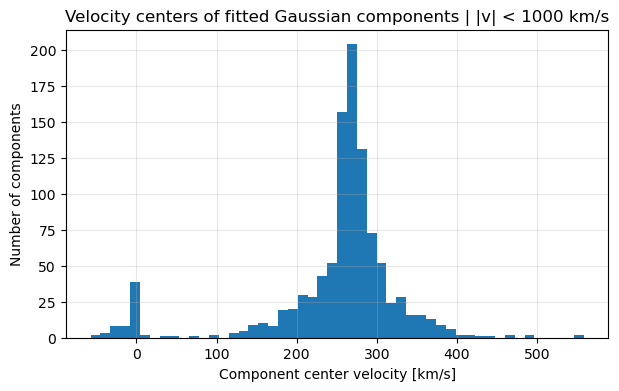

In [17]:
import matplotlib.pyplot as plt

vel = df_components["mean_kms"]

vel_filtered = vel[np.abs(vel) < 1000]

plt.figure(figsize=(7, 4))
plt.hist(vel_filtered, bins=50)
plt.xlabel("Component center velocity [km/s]")
plt.ylabel("Number of components")
plt.title("Velocity centers of fitted Gaussian components | |v| < 1000 km/s")
plt.grid(alpha=0.3)
plt.show()

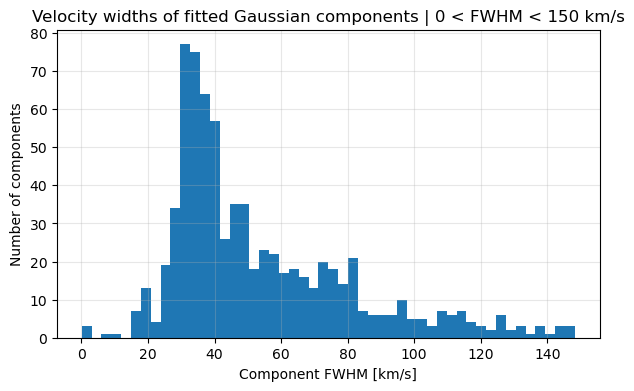

In [18]:
fwhm = df_components["fwhm_kms"]

fwhm_filtered = fwhm[(fwhm > 0) & (fwhm < 150)]

plt.figure(figsize=(7, 4))
plt.hist(fwhm_filtered, bins=50)
plt.xlabel("Component FWHM [km/s]")
plt.ylabel("Number of components")
plt.title("Velocity widths of fitted Gaussian components | 0 < FWHM < 150 km/s")
plt.grid(alpha=0.3)
plt.show()